1. На основе учебного ноутбука проведите финальную подготовку данных. Иизмените количество сегментирующих классов с `16` на `5`.

2. Проведите суммарно не менее `10` экспериментов и визуализируйте их результаты (включая точность обучения сетей на одинаковом количестве эпох, например, на `7`):

  - изменив `filters` в сверточных слоях
  - изменив `kernel_size` в сверточных слоях
  - изменив активационную функцию в скрытых слоях с `relu` на `linear` или/и `selu`, `elu`.

**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

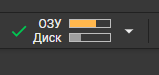



Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

In [1]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K

import os
import gc
import time
import random
import gdown
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import seaborn as sns
sns.set_style("darkgrid")


In [2]:
# Скачиваем архив с изображениями
dataset_url = "https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip"
archive_name = "construction_256x192.zip"

gdown.download(dataset_url, archive_name, quiet=False)

# Распаковываем архив
!unzip -qo construction_256x192.zip

print("Датасет загружен и распакован")


Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:15<00:00, 13.9MB/s]


Датасет загружен и распакован.


In [3]:
IMG_WIDTH = 192
IMG_HEIGHT = 256

TRAIN_DIR = "train"
VAL_DIR = "val"

FLOOR = (100, 100, 100)
CEILING = (0, 0, 100)
WALL = (0, 100, 0)
COLUMN = (100, 0, 0)
APERTURE = (0, 100, 100)
DOOR = (100, 0, 100)
WINDOW = (100, 100, 0)
EXTERNAL = (200, 200, 200)
RAILINGS = (0, 200, 0)
BATTERY = (200, 0, 0)
PEOPLE = (0, 200, 200)
LADDER = (0, 0, 200)
INVENTORY = (200, 0, 200)
LAMP = (200, 200, 0)
WIRE = (0, 100, 200)
BEAM = (100, 0, 200)

CLASS_GROUPS = {
    0: [WALL, COLUMN, BEAM],
    1: [FLOOR, CEILING],
    2: [APERTURE, DOOR, WINDOW],
    3: [RAILINGS, BATTERY, LADDER, INVENTORY, LAMP, WIRE],
    4: [EXTERNAL, PEOPLE],
}

def load_images(folder, part):
    folder_path = os.path.join(folder, part)
    file_names = sorted(os.listdir(folder_path))
    images = []

    for name in file_names:
        img_path = os.path.join(folder_path, name)
        images.append(image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT)))

    return images

def images_to_float_array(images):
    return np.asarray([image.img_to_array(img) for img in images], dtype="float32") / 255.0

def convert_masks_to_sparse_labels(mask_images):
    prepared_masks = []

    for mask in mask_images:
        rgb_mask = np.asarray(mask)
        class_mask = np.zeros((IMG_WIDTH, IMG_HEIGHT, 1), dtype="uint8")

        for class_id, rgb_values in CLASS_GROUPS.items():
            for color in rgb_values:
                pixels = np.all(rgb_mask == color, axis=-1)
                class_mask[pixels] = class_id

        prepared_masks.append(class_mask)

    return np.asarray(prepared_masks)

print("Загружаем исходные изображения...")
train_images = load_images(TRAIN_DIR, "original")
val_images = load_images(VAL_DIR, "original")

x_train = images_to_float_array(train_images)
x_val = images_to_float_array(val_images)

# Удаляем временные списки, чтобы не держать лишние копии изображений в памяти
del train_images, val_images
gc.collect()

print("Загружаем маски и переводим их из 16 цветов в 5 классов...")
train_masks = load_images(TRAIN_DIR, "segment")
val_masks = load_images(VAL_DIR, "segment")

y_train_sparse = convert_masks_to_sparse_labels(train_masks)
y_val_sparse = convert_masks_to_sparse_labels(val_masks)

del train_masks, val_masks
gc.collect()

print("Данные подготовлены")
print("x_train:", x_train.shape)
print("y_train_sparse:", y_train_sparse.shape)
print("x_val:", x_val.shape)
print("y_val_sparse:", y_val_sparse.shape)


Загружаем исходные изображения...
Загружаем маски и переводим их из 16 цветов в 5 классов...
Данные подготовлены.
x_train: (1900, 192, 256, 3)
y_train_sparse: (1900, 192, 256, 1)
x_val: (100, 192, 256, 3)
y_val_sparse: (100, 192, 256, 1)


In [4]:
def build_small_unet(input_shape, base_filters, conv_kernel, hidden_activation):
    model_input = Input(shape=input_shape)

    # Энкодер - извлекаем признаки и уменьшаем размер
    enc_conv = Conv2D(
        base_filters,
        (conv_kernel, conv_kernel),
        activation=hidden_activation,
        padding="same"
    )(model_input)
    enc_pool = MaxPooling2D(pool_size=(2, 2))(enc_conv)

    # Центральный блок модели
    middle = Conv2D(
        base_filters * 2,
        (conv_kernel, conv_kernel),
        activation=hidden_activation,
        padding="same"
    )(enc_pool)

    # Декодер - возвращаем размер карты признаков к исходному
    upsampled = Conv2DTranspose(
        base_filters,
        (2, 2),
        strides=(2, 2),
        padding="same"
    )(middle)

    # Соединяем признаки энкодера и декодера через skip-связь
    merged = concatenate([enc_conv, upsampled], axis=3)

    dec_conv = Conv2D(
        base_filters,
        (conv_kernel, conv_kernel),
        activation=hidden_activation,
        padding="same"
    )(merged)

    model_output = Conv2D(5, (1, 1), activation="softmax", padding="same")(dec_conv)

    return Model(inputs=model_input, outputs=model_output)


In [5]:
# 10 экспериментов
experiment_plan = [
    {"filters": 16, "kernel": 3, "activation": "relu"},
    {"filters": 32, "kernel": 3, "activation": "relu"},
    {"filters": 64, "kernel": 3, "activation": "relu"},
    {"filters": 32, "kernel": 5, "activation": "relu"},
    {"filters": 32, "kernel": 7, "activation": "relu"},
    {"filters": 32, "kernel": 3, "activation": "linear"},
    {"filters": 32, "kernel": 3, "activation": "selu"},
    {"filters": 32, "kernel": 3, "activation": "elu"},
    {"filters": 16, "kernel": 5, "activation": "elu"},
    {"filters": 64, "kernel": 5, "activation": "selu"},
]

EPOCHS_COUNT = 7
BATCH_SIZE = 8
LEARNING_RATE = 1e-4

history_logs = {}
final_accuracies = {}

def clear_memory():
    K.clear_session()
    gc.collect()

def make_experiment_name(number, params):
    return f"Опыт {number}: F={params['filters']}, K={params['kernel']}, A={params['activation']}"

for exp_number, params in enumerate(experiment_plan, start=1):
    print(f"\nЗапуск эксперимента {exp_number} из {len(experiment_plan)}")
    print(
        "Параметры:",
        f"filters={params['filters']},",
        f"kernel={params['kernel']},",
        f"activation={params['activation']}"
    )

    clear_memory()
    time.sleep(1)

    current_model = build_small_unet(
        input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),
        base_filters=params["filters"],
        conv_kernel=params["kernel"],
        hidden_activation=params["activation"]
    )

    current_model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    current_history = current_model.fit(
        x_train,
        y_train_sparse,
        epochs=EPOCHS_COUNT,
        batch_size=BATCH_SIZE,
        validation_data=(x_val, y_val_sparse),
        verbose=1
    )

    exp_name = make_experiment_name(exp_number, params)
    val_acc = current_history.history["val_accuracy"]

    history_logs[exp_name] = val_acc
    final_accuracies[exp_name] = val_acc[-1]

    print(f"Эксперимент завершён. Итоговая val_accuracy: {final_accuracies[exp_name]:.4f}")

    # Удаляем модель и историю обучения
    del current_model, current_history
    clear_memory()

print("\nВсе 10 экспериментов завершены.")



Запуск эксперимента 1 из 10
Параметры: filters=16, kernel=3, activation=relu
Epoch 1/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.4966 - loss: 1.3575 - val_accuracy: 0.5294 - val_loss: 1.2252
Epoch 2/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5273 - loss: 1.2531 - val_accuracy: 0.5294 - val_loss: 1.2066
Epoch 3/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5272 - loss: 1.1982 - val_accuracy: 0.5303 - val_loss: 1.1658
Epoch 4/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5304 - loss: 1.1571 - val_accuracy: 0.5325 - val_loss: 1.1498
Epoch 5/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5399 - loss: 1.1346 - val_accuracy: 0.5337 - val_loss: 1.1449
Epoch 6/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5443 - loss: 1.1212 - val_accuracy: 0.5373 - val_loss: 1.1283
Epoch 7/7
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5446 - loss: 1.1126 - val_accuracy: 0.5378 - val_loss: 1.1258
Эксперимент завершён. Ито

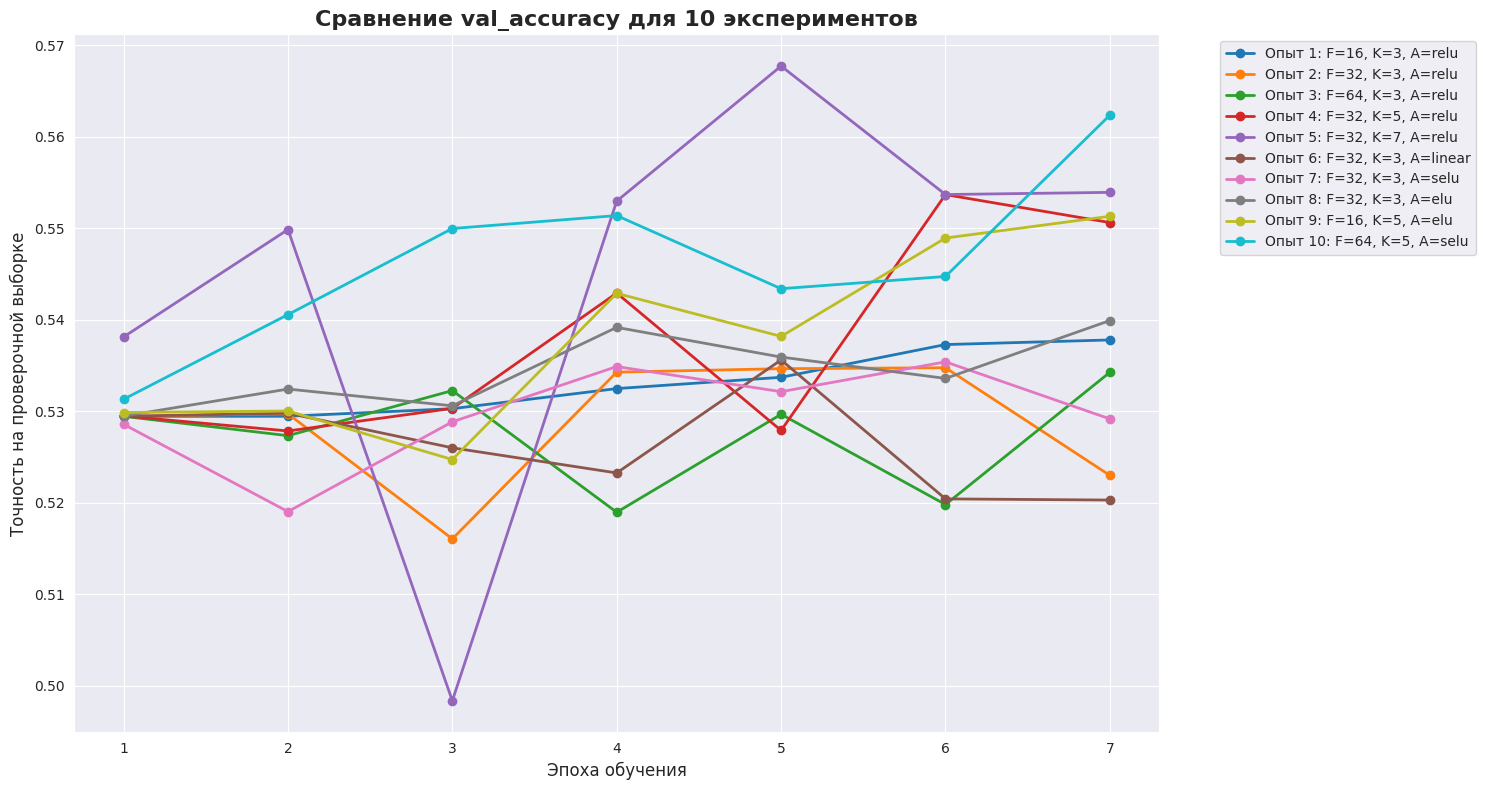


Рейтинг моделей по итоговой val_accuracy:
1. Опыт 10: F=64, K=5, A=selu -> 0.5623
2. Опыт 5: F=32, K=7, A=relu -> 0.5539
3. Опыт 9: F=16, K=5, A=elu -> 0.5513
4. Опыт 4: F=32, K=5, A=relu -> 0.5506
5. Опыт 8: F=32, K=3, A=elu -> 0.5399
6. Опыт 1: F=16, K=3, A=relu -> 0.5378
7. Опыт 3: F=64, K=3, A=relu -> 0.5342
8. Опыт 7: F=32, K=3, A=selu -> 0.5291
9. Опыт 2: F=32, K=3, A=relu -> 0.5230
10. Опыт 6: F=32, K=3, A=linear -> 0.5203


In [6]:
def show_accuracy_comparison(history_dict, epochs_count):
    plt.figure(figsize=(15, 8))

    epochs = range(1, epochs_count + 1)

    for experiment_name, values in history_dict.items():
        plt.plot(epochs, values, marker="o", linewidth=2, label=experiment_name)

    plt.title("Сравнение val_accuracy для 10 экспериментов", fontsize=16, fontweight="bold")
    plt.xlabel("Эпоха обучения", fontsize=12)
    plt.ylabel("Точность на проверочной выборке", fontsize=12)
    plt.xticks(list(epochs))
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
    plt.tight_layout()
    plt.show()

def print_model_rating(scores):
    print("\nРейтинг моделей по итоговой val_accuracy:")

    sorted_scores = sorted(scores.items(), key=lambda pair: pair[1], reverse=True)

    for place, (model_name, score) in enumerate(sorted_scores, start=1):
        print(f"{place}. {model_name} -> {score:.4f}")

show_accuracy_comparison(history_logs, EPOCHS_COUNT)
print_model_rating(final_accuracies)
